In [1]:
import pandas as pd
import missingno as msno
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Path to FRED data folder relative to your notebooks working directory
fred_data_dir = Path("..") / "data" / "raw" / "fred data"

# Directly load the known files
md = pd.read_csv(fred_data_dir / "transf_md.csv")
qd = pd.read_csv(fred_data_dir / "transf_qd.csv")

In [3]:
# Convert the 'date' columns to datetime format
md['date'] = pd.to_datetime(md['date'])
qd['date'] = pd.to_datetime(qd['date'])

# Print start and end dates for each dataset
print("Monthly data range:")
print("Start:", md['date'].min())
print("End  :", md['date'].max())

print("\nQuarterly data range:")
print("Start:", qd['date'].min())
print("End  :", qd['date'].max())

Monthly data range:
Start: 1959-01-01 00:00:00
End  : 2025-03-01 00:00:00

Quarterly data range:
Start: 1959-03-01 00:00:00
End  : 2025-03-01 00:00:00


In [4]:
# Set date as index
md = md.set_index('date').sort_index()

# Create a complete monthly date range from start to end
full_month_range = pd.date_range(start=md.index.min(), end=md.index.max(), freq='MS')

# Compare with existing dates
missing_months = full_month_range.difference(md.index)

print("Missing monthly dates:")
print(missing_months)


Missing monthly dates:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [5]:
# For qd: assumes 'date' is datetime and qd is sorted by date
qd = qd.set_index('date').sort_index()

# Create quarterly dates using '03-01', '06-01', etc.
full_quarters = pd.date_range(start=qd.index.min(), end=qd.index.max(), freq='3MS')

# Find missing quarterly periods
missing_quarters = full_quarters.difference(qd.index)

print("Missing quarterly dates:")
print(missing_quarters)


Missing quarterly dates:
DatetimeIndex([], dtype='datetime64[ns]', freq='3MS')


As target quarterly candidates i think we can start with:
INDPRO (column G), CPIAUCSL (col DR), or PCEPI (col CT), and UNRATE (col BI)
I added pdf called Fred-md updated appendix to the joint folder (Attention MIDAS -> fred data) 
It has decription of all transformation codes and brief series decriptions as well

After our meeting, we agreed we should try something like Y (industrial production INTPROD quarterly) - X something monthly (a subset).

In [7]:
qd.columns

Index(['Unnamed: 0', 'GDPC1', 'PCECC96', 'PCDGx', 'PCESVx', 'PCNDx', 'GPDIC1',
       'FPIx', 'Y033RC1Q027SBEAx', 'PNFIx',
       ...
       'TNWMVBSNNCBBDIx', 'TLBSNNBx', 'TLBSNNBBDIx', 'TABSNNBx', 'TNWBSNNBx',
       'TNWBSNNBBDIx', 'CNCFx', 'S&P 500', 'S&P div yield', 'S&P PE ratio'],
      dtype='object', length=246)

In [8]:
md.columns

Index(['Unnamed: 0', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx',
       'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=127)

Monthly Data Missingness:


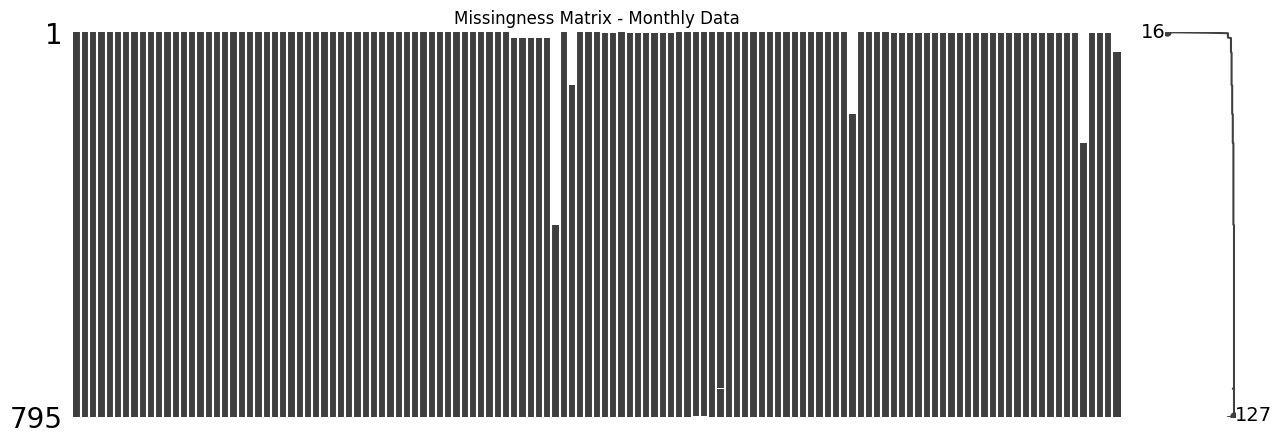

In [15]:
# Monthly: missingness matrix
print("Monthly Data Missingness:")
msno.matrix(md, figsize=(15, 5), sparkline=True)
plt.title("Missingness Matrix - Monthly Data")
plt.show()

Quarterly Data Missingness:


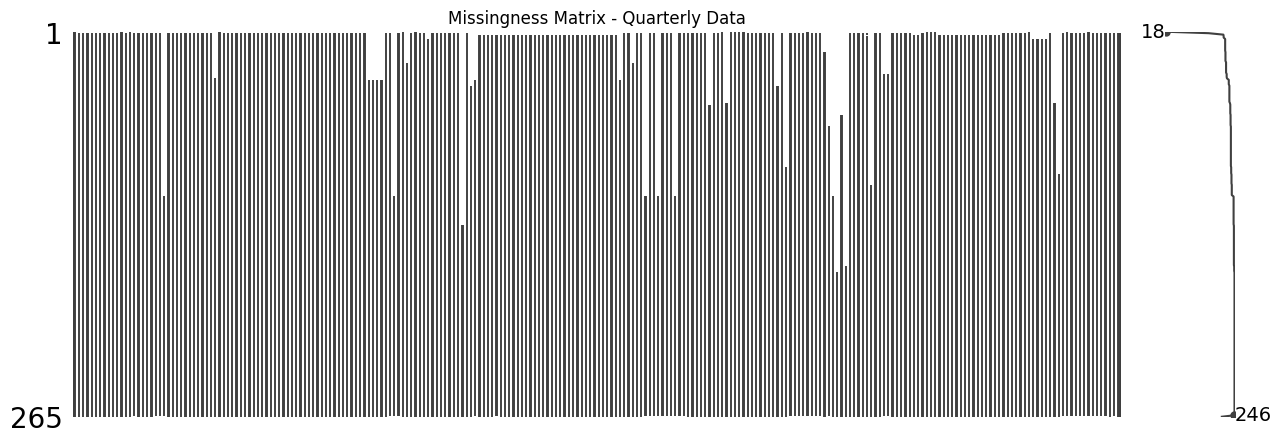

In [16]:
# Quarterly: missingness matrix
print("Quarterly Data Missingness:")
msno.matrix(qd, figsize=(15, 5), sparkline=True)
plt.title("Missingness Matrix - Quarterly Data")
plt.show()

In [35]:
# Remove 'Unnamed: 0' and 'date' from comparison
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

# Compare
common_vars = md_vars & qd_vars
only_in_md = md_vars - qd_vars
only_in_qd = qd_vars - md_vars

print("Variables in both MD and QD:")
print(sorted(common_vars))

print("\nVariables only in MD:")
print(sorted(only_in_md))

print("\nVariables only in QD:")
print(sorted(only_in_qd))

Variables in both MD and QD:
['AAA', 'AAAFFM', 'AMDMNOx', 'AMDMUOx', 'ANDENOx', 'AWHMAN', 'AWOTMAN', 'BAA', 'BUSINVx', 'CE16OV', 'CES0600000007', 'CES0600000008', 'CLAIMSx', 'CMRMTSPLx', 'CPIAPPSL', 'CPIAUCSL', 'CPIMEDSL', 'CPITRNSL', 'CPIULFSL', 'CUMFNS', 'CUSR0000SA0L2', 'CUSR0000SA0L5', 'CUSR0000SAC', 'CUSR0000SAD', 'CUSR0000SAS', 'DMANEMP', 'DTCOLNVHFNM', 'DTCTHFNM', 'EXCAUSx', 'EXJPUSx', 'EXSZUSx', 'EXUSUKx', 'FEDFUNDS', 'GS1', 'GS10', 'GS5', 'HOUST', 'HOUSTMW', 'HOUSTNE', 'HOUSTS', 'HOUSTW', 'INDPRO', 'INVEST', 'IPB51222S', 'IPBUSEQ', 'IPCONGD', 'IPDCONGD', 'IPDMAT', 'IPFINAL', 'IPFUELS', 'IPMANSICS', 'IPMAT', 'IPNCONGD', 'IPNMAT', 'ISRATIOx', 'M2REAL', 'MANEMP', 'NDMANEMP', 'NONBORRES', 'OILPRICEx', 'PAYEMS', 'PERMIT', 'PERMITMW', 'PERMITNE', 'PERMITS', 'PERMITW', 'PPICMM', 'S&P 500', 'S&P PE ratio', 'S&P div yield', 'SRVPRD', 'T5YFFM', 'TB3MS', 'TB3SMFFM', 'TB6MS', 'TOTRESNS', 'TWEXAFEGSMTHx', 'UEMP15T26', 'UEMP27OV', 'UEMP5TO14', 'UEMPLT5', 'UEMPMEAN', 'UMCSENTx', 'UNRATE', 'U

In [22]:
md[['CPIAUCSL', 'PCEPI', 'UNRATE']].head(20)

,CPIAUCSL,PCEPI,UNRATE
date,,,
1959-01-01,NaN,NaN,NaN
1959-02-01,NaN,NaN,-0.1
1959-03-01,-0.000690,-0.000330,-0.3
1959-04-01,0.001380,0.001315,-0.4
1959-05-01,0.001723,-0.001448,-0.1
1959-06-01,0.000339,0.002360,-0.1
1959-07-01,-0.001034,-0.000792,0.1
1959-08-01,-0.000345,-0.000657,0.1
1959-09-01,0.001367,0.001170,0.3


In [36]:
monthly_vars = ['CPIAUCSL', 'PCEPI', 'UNRATE']
quarterly_vars = ['INDPRO']

# Extract available columns (excluding metadata)
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

# Check each variable
print("Monthly variable availability:")
for var in monthly_vars:
    in_md = var in md_vars
    in_qd = var in qd_vars
    print(f"{var}: {'present in MD' if in_md else 'not in MD'} | {'present in QD' if in_qd else 'not in QD'}")

print("\nQuarterly variable availability:")
for var in quarterly_vars:
    in_md = var in md_vars
    in_qd = var in qd_vars
    print(f"{var}: {'present in MD' if in_md else 'not in MD'} | {'present in QD' if in_qd else 'not in QD'}")


Monthly variable availability:
CPIAUCSL: present in MD | present in QD
PCEPI: present in MD | not in QD
UNRATE: present in MD | present in QD

Quarterly variable availability:
INDPRO: present in MD | present in QD


In [26]:
def create_long_format_FRED(md_path: Path, qd_path: Path, monthly_vars: list, quarterly_vars: list) -> pd.DataFrame:
    """
    Transforms selected monthly and quarterly variables into a unified long-format DataFrame,
    preserving natural frequencies and ordering quarterly entries after monthly ones on the same date.

    Parameters:
        md_path (Path): path to the transformed monthly CSV
        qd_path (Path): path to the transformed quarterly CSV
        monthly_vars (list): list of variable names to extract from monthly data
        quarterly_vars (list): list of variable names to extract from quarterly data

    Returns:
        pd.DataFrame: long-format DataFrame with columns: Timestamp, Variable, Value, Frequency (M or Q)
    """

    # Load datasets
    md = pd.read_csv(md_path, parse_dates=['date'])
    qd = pd.read_csv(qd_path, parse_dates=['date'])

    # Filter and drop missing independently
    md_filtered = md[['date'] + monthly_vars].dropna(subset=monthly_vars)
    qd_filtered = qd[['date'] + quarterly_vars].dropna(subset=quarterly_vars)

    # Melt into long format
    md_long = md_filtered.melt(id_vars='date', var_name='Variable', value_name='Value')
    qd_long = qd_filtered.melt(id_vars='date', var_name='Variable', value_name='Value')

    # Tag frequencies
    md_long['Frequency'] = 'M'
    qd_long['Frequency'] = 'Q'

    # Combine and rename
    long_df = pd.concat([md_long, qd_long], ignore_index=True)
    long_df.rename(columns={'date': 'Timestamp'}, inplace=True)

    # Ensure M comes before Q for the same timestamp
    freq_order = {'M': 0, 'Q': 1}
    long_df['FreqSort'] = long_df['Frequency'].map(freq_order)

    long_df = long_df.sort_values(['Timestamp', 'FreqSort']).drop(columns='FreqSort').reset_index(drop=True)

    return long_df


In [27]:
base_path = Path("..") / "data" / "raw" / "fred data"
md_path = base_path / "transf_md.csv"
qd_path = base_path / "transf_qd.csv"

# Specify the variable names you want to extract
monthly_vars = ['CPIAUCSL', 'PCEPI', 'UNRATE']
quarterly_vars = ['INDPRO']

# Generate the long-format DataFrame
long_df = create_long_format_FRED(md_path, qd_path, monthly_vars, quarterly_vars)

long_df.head()

,Timestamp,Variable,Value,Frequency
0,1959-03-01,CPIAUCSL,-0.000690,M
1,1959-03-01,PCEPI,-0.000330,M
2,1959-03-01,UNRATE,-0.300000,M
3,1959-04-01,CPIAUCSL,0.001380,M
4,1959-04-01,PCEPI,0.001315,M


In [28]:
long_df.head(20)

,Timestamp,Variable,Value,Frequency
0,1959-03-01,CPIAUCSL,-0.000690,M
1,1959-03-01,PCEPI,-0.000330,M
2,1959-03-01,UNRATE,-0.300000,M
3,1959-04-01,CPIAUCSL,0.001380,M
4,1959-04-01,PCEPI,0.001315,M
5,1959-04-01,UNRATE,-0.400000,M
6,1959-05-01,CPIAUCSL,0.001723,M
7,1959-05-01,PCEPI,-0.001448,M
8,1959-05-01,UNRATE,-0.100000,M
9,1959-06-01,CPIAUCSL,0.000339,M


In [32]:
# Count number of entries by frequency
frequency_counts = long_df['Variable'].value_counts()

print("Frequency counts:")
print(frequency_counts)


Frequency counts:
Variable
CPIAUCSL    793
PCEPI       793
UNRATE      793
INDPRO      264
Name: count, dtype: int64


In [33]:
264*3

792

<Axes: >

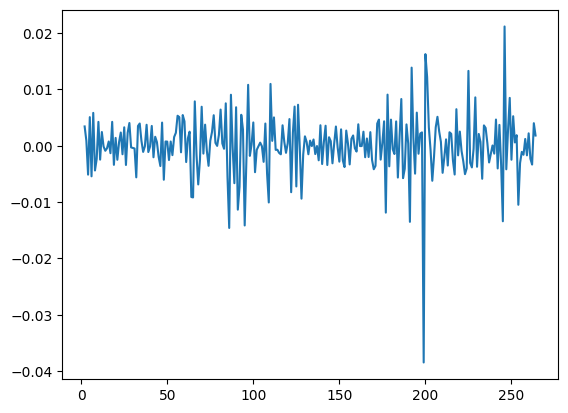

In [6]:
qd['CPIAUCSL'].plot()

In [8]:
md.columns

Index(['Unnamed: 0', 'date', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx',
       'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=128)